In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Define file paths
train_file = "data/train.csv"
test_file = "data/test.csv"

print(f"\nProcessing train file: {train_file}")
df_train = pd.read_csv(train_file)

print(f"\nProcessing test file: {test_file}")
df_test = pd.read_csv(test_file)


Processing train file: data/train.csv

Processing test file: data/test.csv


In [8]:
print("Shape df_train : ", df_train.shape)
print("Shape df_test : ", df_test.shape)

df_train = df_train.drop("ID", axis=1)
df_test = df_test.drop("ID", axis=1)
print(df_train.head())

Shape df_train :  (104998, 12)
Shape df_test :  (45002, 11)
       var1  var2  var3      var4     var5  var6  var7  var8  var9  var10  \
0  0.766127    45     2  0.802982   9120.0    13     0     6     0    2.0   
1  0.957151    40     0  0.121876   2600.0     4     0     0     0    1.0   
2  0.658180    38     1  0.085113   3042.0     2     1     0     0    0.0   
3  0.233810    30     0  0.036050   3300.0     5     0     0     0    0.0   
4  0.907239    49     1  0.024926  63588.0     7     0     1     0    0.0   

   TARGET  
0       1  
1       0  
2       0  
3       0  
4       0  


In [ ]:
import io

from IPython.display import HTML, display

# Create string buffers to capture info output
buffer1 = io.StringIO()
buffer2 = io.StringIO()

# Write dataframe info to the buffers
df_train.info(buf=buffer1)
df_test.info(buf=buffer2)

# Get the captured output as strings
info1 = buffer1.getvalue()
info2 = buffer2.getvalue()

# Replace spaces with non-breaking spaces and newlines with HTML breaks
info1_html = info1.replace(" ", "&nbsp;").replace("\n", "<br>")
info2_html = info2.replace(" ", "&nbsp;").replace("\n", "<br>")

# Display side by side using HTML
html_content = f"""
<div style="display: flex; font-family: monospace; white-space: pre;">
    <div style="flex: 50%;">
        <h4>Train DataFrame Info</h4>
        {info1_html}
    </div>
    <div style="flex: 50%;">
        <h4>Test DataFrame Info</h4>
        {info2_html}
    </div>
</div>
"""

display(HTML(html_content))

In [ ]:
print(f"Proportion of missing var5 in train: {100 - (84226 * 100 / 104998)}%")
print(f"Proportion of missing var5 in test: {100 - (36043 * 100 / 45002)}%")

print(
    f"\nProportion of missing var10 in train: {100 - (102238 * 100 / 104998)}%"
)
print(f"Proportion of missing var10 in test: {100 - (43838 * 100 / 45002)}%")

Proportion of missing var5 in train: 19.783233966361266%
Proportion of missing var5 in test: 19.908004088707173%

Proportion of missing var10 in train: 2.6286214975523308%
Proportion of missing var10 in test: 2.586551708812948%


About 2500 rows do not have a value for var10 -> delete these rows (only 2% of the data)

About 20000 rows do not have a value for var5 -> deleting these rows might not be suitable, we need to try and see impact on train with validation with:

- delete the rows
- replace with mean or median values
- see if another columns is highly correlated: if yes, then we can delete column var5

(https://www.kaggle.com/discussions/questions-and-answers/396670)


In [ ]:
# Quantiles df_train
desc_df = df_train.describe().T
desc_df = desc_df.drop("count", axis=1)
desc_df = desc_df.drop("TARGET", axis=0)
desc_df["unique_values"] = [df_train[col].nunique() for col in desc_df.index]
desc_df["type"] = df_train.loc[:, df_train.columns != "ID"].dtypes
desc_df

,mean,std,min,25%,50%,75%,max,unique_values,type
var1,6.073156,257.859625,0.0,0.030002,0.155936,0.561917,50708.0,88523,float64
var2,52.261014,14.768987,0.0,41.000000,52.000000,63.000000,107.0,85,int64
var3,0.422665,4.221443,0.0,0.000000,0.000000,0.000000,98.0,15,int64
var4,354.627892,2104.703046,0.0,0.175067,0.366162,0.866584,329664.0,82416,float64
var5,6636.738727,13594.929730,0.0,3400.000000,5400.000000,8228.000000,3008750.0,12038,float64
var6,8.442294,5.136260,0.0,5.000000,8.000000,11.000000,58.0,57,int64
var7,0.268386,4.197747,0.0,0.000000,0.000000,0.000000,98.0,18,int64
var8,1.018696,1.134364,0.0,0.000000,1.000000,2.000000,54.0,28,int64
var9,0.242186,4.184389,0.0,0.000000,0.000000,0.000000,98.0,13,int64
var10,0.757957,1.116196,0.0,0.000000,0.000000,1.000000,20.0,12,float64


In [ ]:
# Quantiles df_test
desc_df = df_test.describe().T
desc_df = desc_df.drop("count", axis=1)
desc_df["unique_values"] = [df_test[col].nunique() for col in desc_df.index]
desc_df["type"] = df_test.loc[:, df_test.columns != "ID"].dtypes
desc_df

,mean,std,min,25%,50%,75%,max,unique_values,type
var1,5.990767,229.740401,0.0,0.029494,0.150139,0.553120,22000.0,38443,float64
var2,52.374983,14.778437,21.0,41.000000,52.000000,63.000000,109.0,82,int64
var3,0.417226,4.125178,0.0,0.000000,0.000000,0.000000,98.0,14,int64
var4,349.218744,1872.514607,0.0,0.175099,0.367172,0.874006,307001.0,37703,float64
var5,6748.463835,16079.576118,0.0,3400.000000,5409.000000,8272.000000,1794060.0,8381,float64
var6,8.477179,5.168465,0.0,5.000000,8.000000,11.000000,57.0,55,int64
var7,0.260344,4.102213,0.0,0.000000,0.000000,0.000000,98.0,18,int64
var8,1.017177,1.118992,0.0,0.000000,1.000000,2.000000,25.0,21,int64
var9,0.236190,4.086258,0.0,0.000000,0.000000,0.000000,98.0,10,int64
var10,0.755509,1.112504,0.0,0.000000,0.000000,1.000000,13.0,12,float64


In [ ]:
df_train["var10"] = df_train["var10"].fillna(-999).astype("int64")
var10_counts = df_train["var10"].value_counts()
print("var10 counts:")
print(var10_counts)


df_train["var8"] = df_train["var8"].fillna(-999).astype("int64")
var8_counts = df_train["var8"].value_counts()
print("var8 counts:")
print(var8_counts)


var10 counts:
var10
 0      60774
 1      18484
 2      13659
 3       6582
-999     2760
 4       2028
 5        539
 6        112
 7         37
 8         16
 10         4
 9          2
 20         1
Name: count, dtype: int64
var8 counts:
var8
0     39309
1     36645
2     22051
3      4438
4      1536
5       468
6       222
7       123
8        64
9        54
10       26
11       14
13       11
12        9
14        5
15        5
17        4
16        2
23        2
25        2
21        1
54        1
26        1
18        1
29        1
19        1
20        1
32        1
Name: count, dtype: int64


**On pourrait considérer var3, car7, var9 et var10 comme des variables à catégories, car elles ont peu de valeurs distinctes.**


TARGET distribution
        COUNT  PERCENTAGE
TARGET                   
0       97992   93.327492
1        7006    6.672508


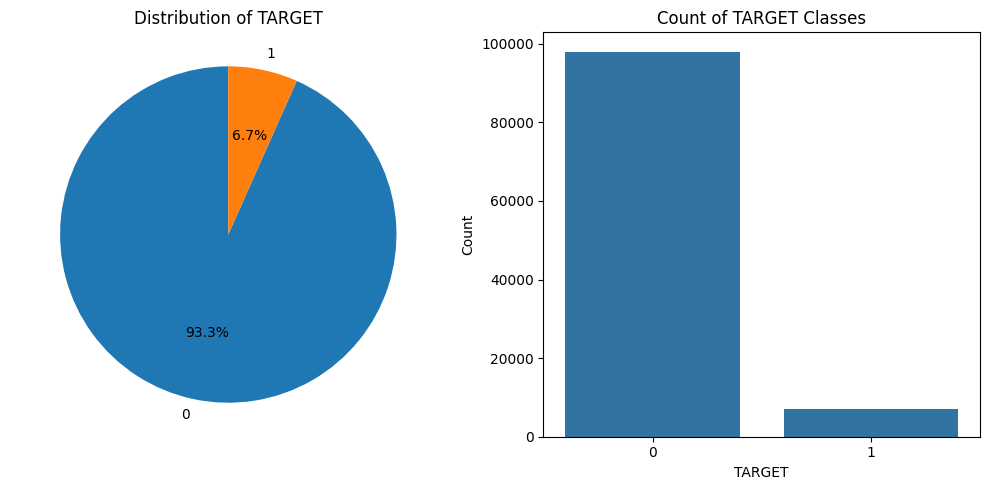

In [ ]:
print("TARGET distribution")
plt.figure(figsize=(10, 5))

# Calculate value counts and percentages
target_counts = df_train["TARGET"].value_counts()
target_percent = 100 * target_counts / len(df_train)

# Print table with counts and percentages
print(pd.DataFrame({"COUNT": target_counts, "PERCENTAGE": target_percent}))

# Create pie chart
plt.subplot(1, 2, 1)
plt.pie(
    target_counts, labels=target_counts.index, autopct="%1.1f%%", startangle=90
)
plt.title("Distribution of TARGET")
plt.axis("equal")  # Equal aspect ratio ensures that pie is drawn as a circle

# Add a bar plot alongside for better visualization
plt.subplot(1, 2, 2)
sns.countplot(x=df_train["TARGET"], data=df_train)
plt.title("Count of TARGET Classes")
plt.xlabel("TARGET")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [15]:
cat_cols = ["var3", "var7", "var9", "var10"]
num_cols = ["var1", "var2", "var4", "var5", "var6", "var8"]

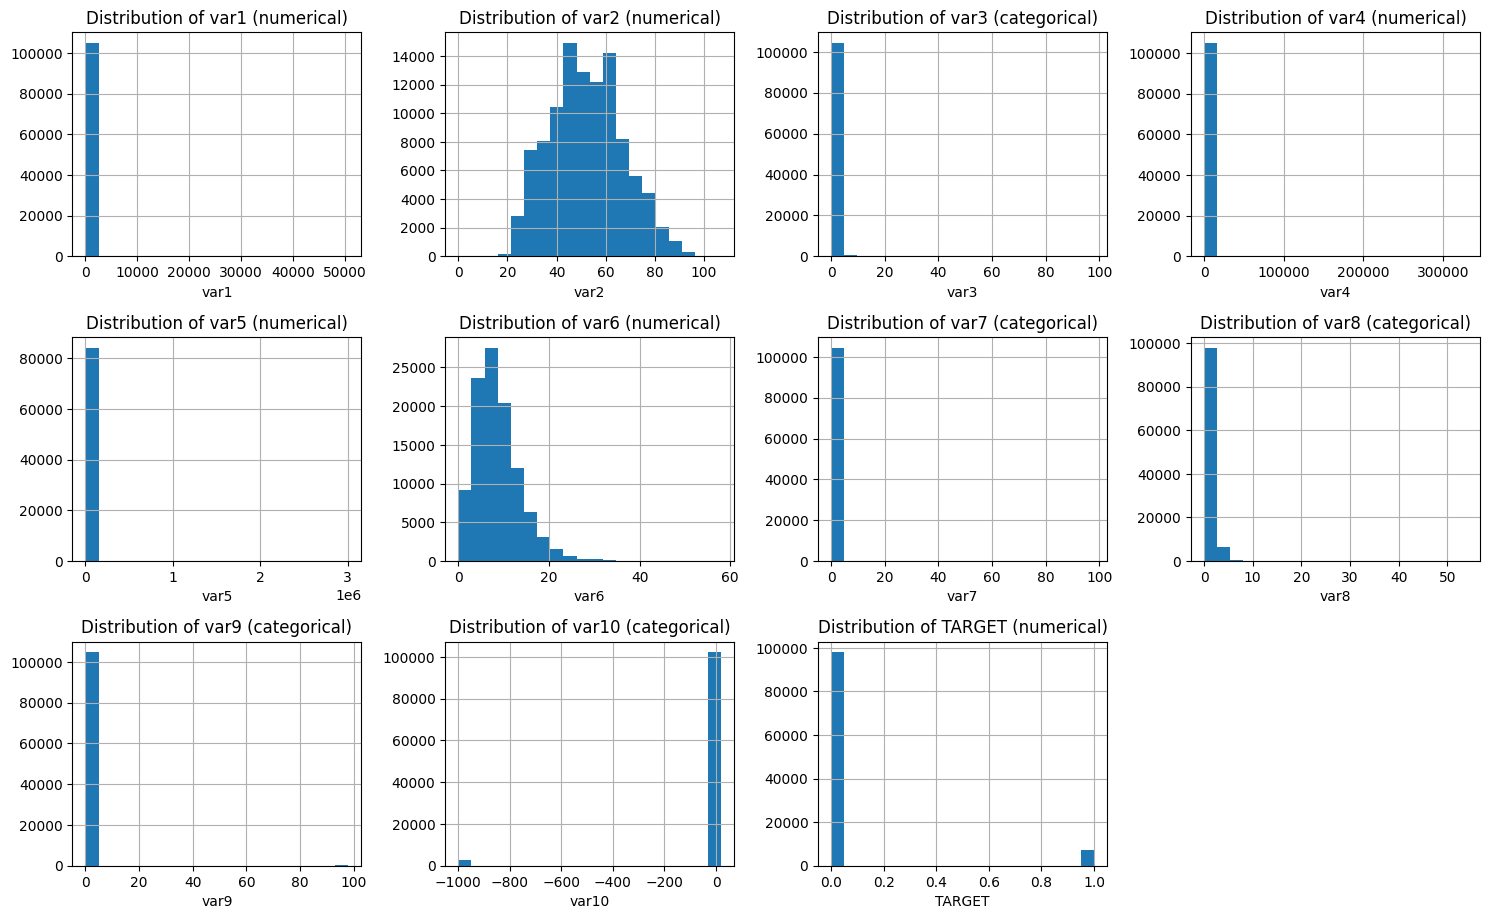

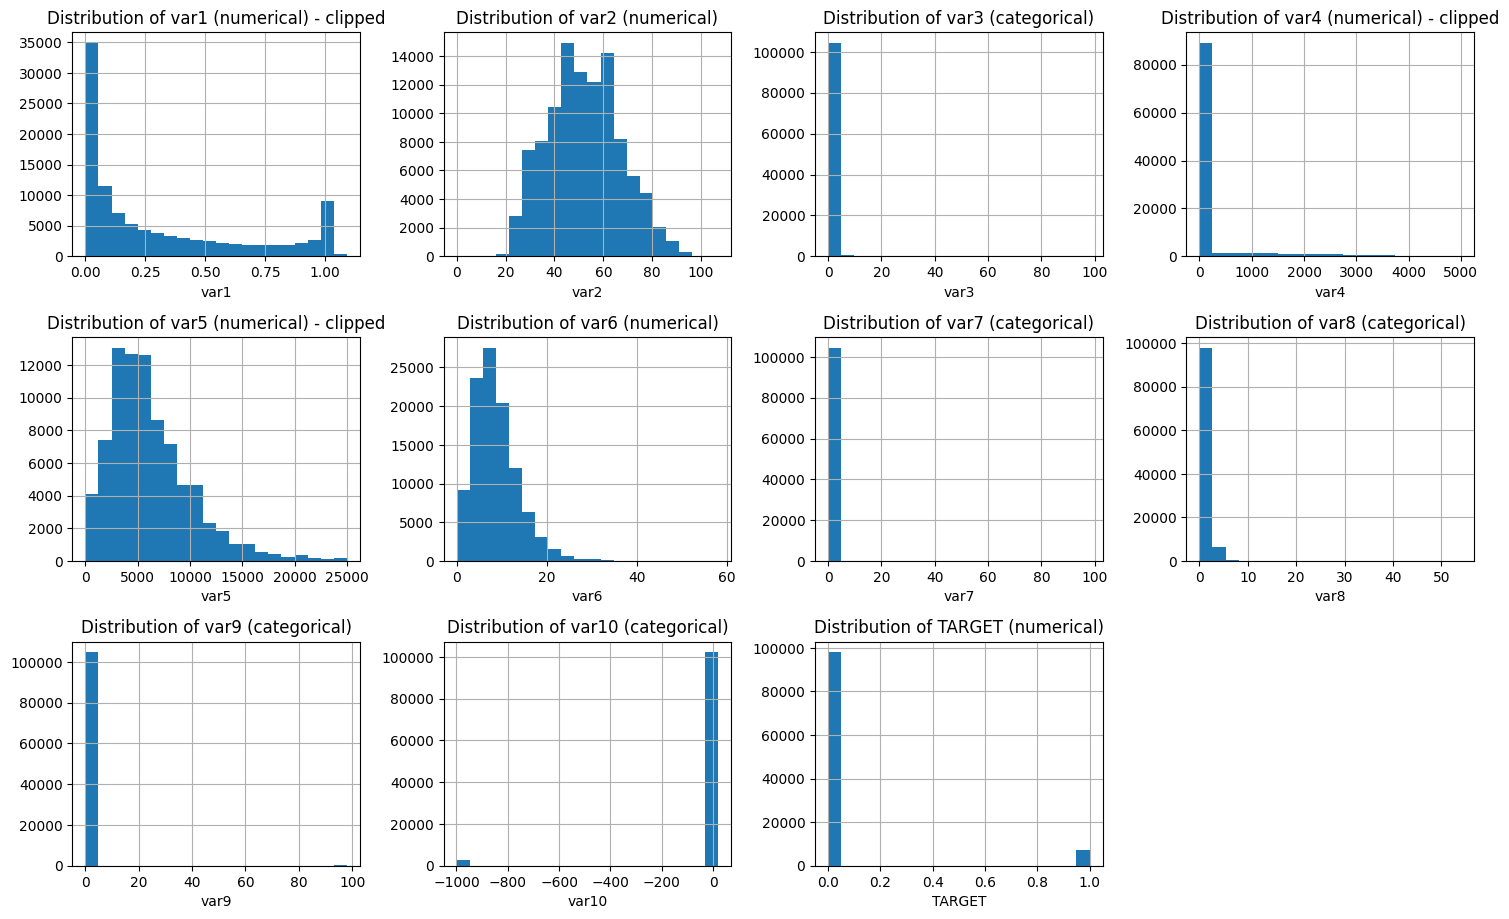

In [ ]:
from math import ceil

# For categorical variables - display in 2 columns


def all_summary(dataframe, cols):
    num_rows = ceil(len(cols) / 2)  # Calculate number of rows needed
    plt.figure(figsize=(15, num_rows * 3))
    for i, col in enumerate(cols):
        # quantiles = [0.01, 0.10, 0.30, 0.50, 0.70, 0.90, 0.99]
        # print(f"##########################################\n{col}")
        # print(dataframe[col].describe(quantiles).T)

        plt.subplot(num_rows, 4, i + 1)  # Arrange in 2 columns
        dataframe[col].hist(bins=20)
        plt.xlabel(col)
        if col in ["var3", "var7", "var8", "var9", "var10"]:
            plt.title(f"Distribution of {col} (categorical)")
        else:
            plt.title(f"Distribution of {col} (numerical)")
    plt.tight_layout()
    plt.show()


def all_summary_filtered(dataframe, cols):
    df_copy = dataframe.copy()
    # For filtered numerical variables
    num_rows = ceil(len(cols) / 2)  # Calculate number of rows needed
    plt.figure(figsize=(15, num_rows * 3))
    for i, col in enumerate(cols):
        # Calculate 0th and 99th centiles
        first_decile = df_copy[col].quantile(0.0)
        ninth_decile = df_copy[col].quantile(0.99)

        # Filter the df_copy

        plt.subplot(num_rows, 4, i + 1)  # Arrange in 2 columns
        if col in ["var3", "var7", "var8", "var9", "var10"]:
            plt.title(f"Distribution of {col} (categorical)")
            filtered_df = df_copy.copy()
        else:
            if col in ["var1", "var4", "var5"]:
                plt.title(f"Distribution of {col} (numerical) - clipped")
                filtered_df = df_copy[
                    (df_copy[col] >= first_decile)
                    & (df_copy[col] <= ninth_decile)
                ]
            else:
                plt.title(f"Distribution of {col} (numerical)")
                filtered_df = df_copy.copy()
        filtered_df[col].hist(bins=20)
        plt.xlabel(col)
    plt.tight_layout()
    plt.show()


all_summary(df_train, df_train.columns)
all_summary_filtered(df_train, df_train.columns)
# print("TARGET distribution in train set")
# cat_summary(df_train, ["TARGET"])

# print("cat columns distribution in train set")
# cat_summary(df_train, cat_cols)

# print("num columns distribution in train set")
# num_summary(df_train, num_cols)

# print("num columns without outliers distribution in train set")
# num_summary_filtered(df_train, num_cols)


TARGET distribution in train set
##########################################
TARGET
        TARGET      Ratio
TARGET                   
0        97992  93.327492
1         7006   6.672508


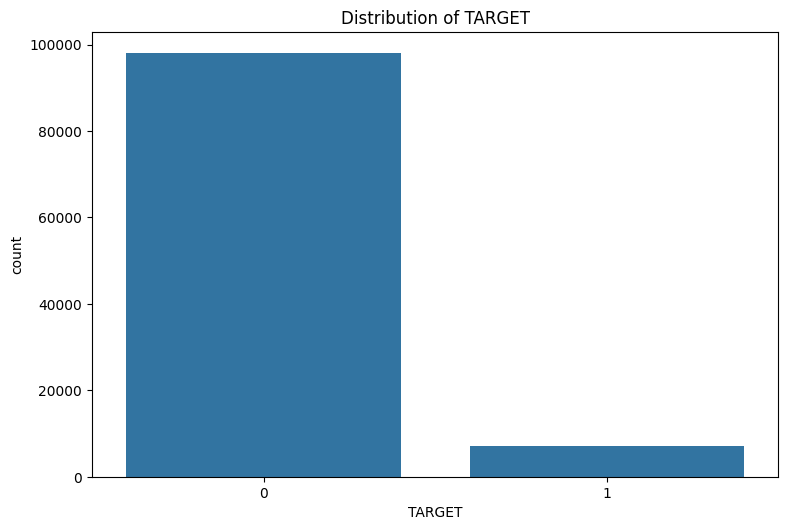

cat columns distribution in train set
##########################################
var3
       var3      Ratio
var3                  
0     88257  84.055887
1     11201  10.667822
2      3182   3.030534
3      1251   1.191451
4       518   0.493343
5       232   0.220957
98      187   0.178099
6        96   0.091430
7        41   0.039048
8        17   0.016191
9         7   0.006667
96        4   0.003810
10        2   0.001905
12        2   0.001905
13        1   0.000952
##########################################
var7
       var7      Ratio
var7                  
0     99105  94.387512
1      3726   3.548639
2      1101   1.048591
3       463   0.440961
4       197   0.187623
98      187   0.178099
5        97   0.092383
6        54   0.051430
7        21   0.020000
9        15   0.014286
8        15   0.014286
10        6   0.005714
96        4   0.003810
11        2   0.001905
13        2   0.001905
15        1   0.000952
14        1   0.000952
17        1   0.000952
###############

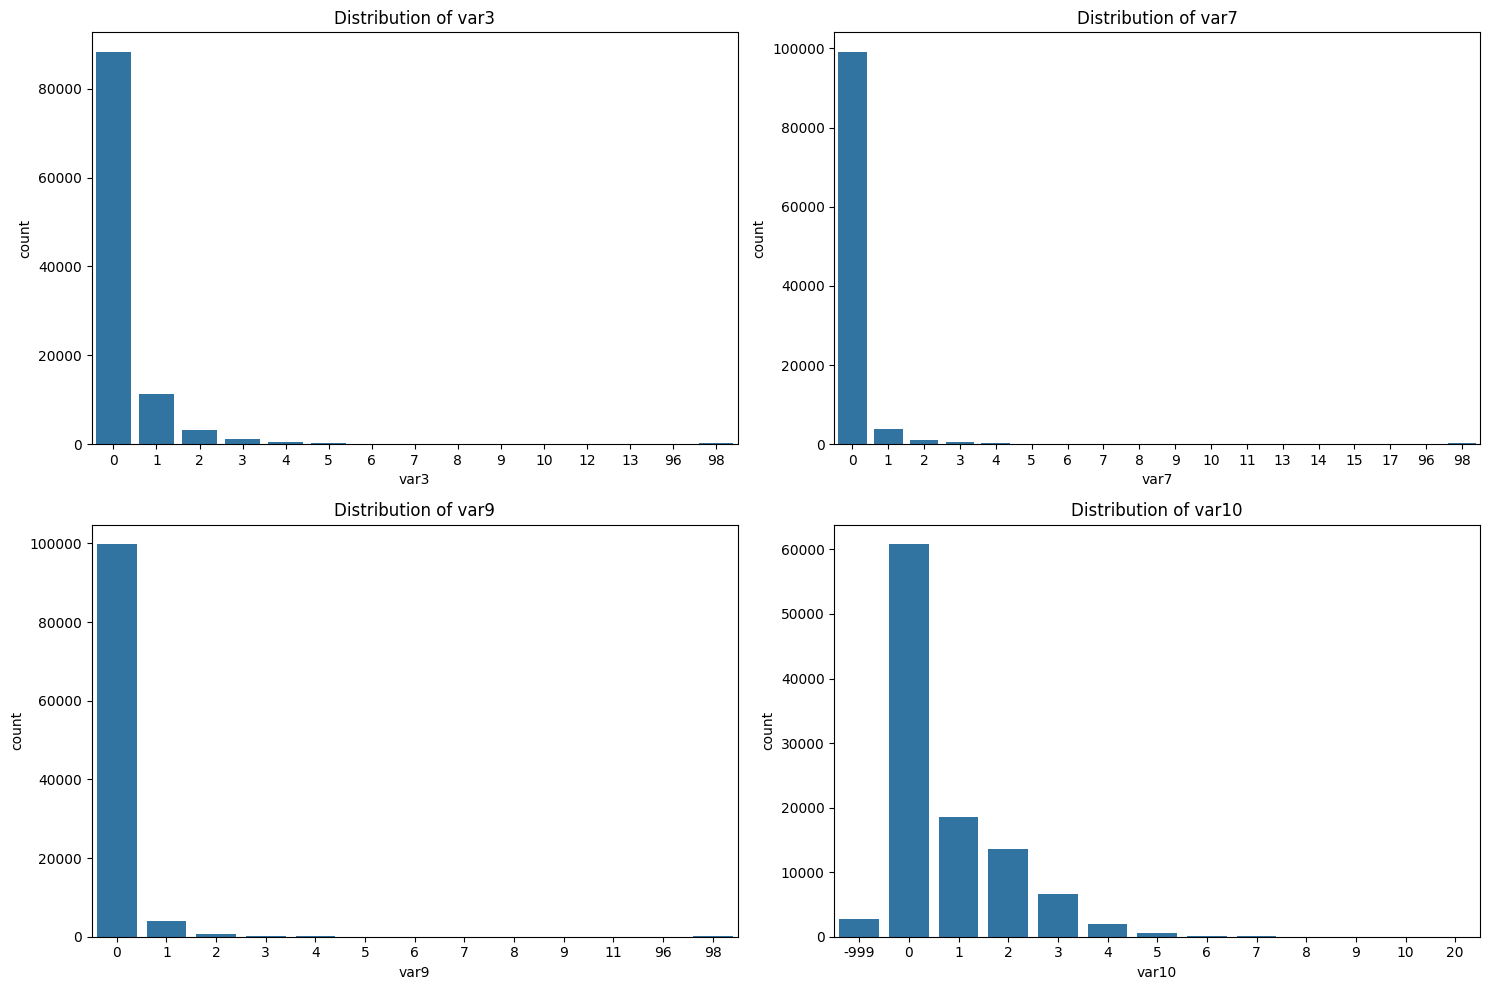

num columns distribution in train set
##########################################
var1
count    104998.000000
mean          6.073156
std         257.859625
min           0.000000
1%            0.000000
10%           0.003001
30%           0.043748
50%           0.155936
70%           0.446722
90%           0.982404
99%           1.092091
max       50708.000000
Name: var1, dtype: float64
##########################################
var2
count    104998.000000
mean         52.261014
std          14.768987
min           0.000000
1%           24.000000
10%          33.000000
30%          44.000000
50%          52.000000
70%          60.000000
90%          72.000000
99%          87.000000
max         107.000000
Name: var2, dtype: float64
##########################################
var4
count    104998.000000
mean        354.627892
std        2104.703046
min           0.000000
1%            0.000000
10%           0.030846
30%           0.213810
50%           0.366162
70%           0.648283
90%  

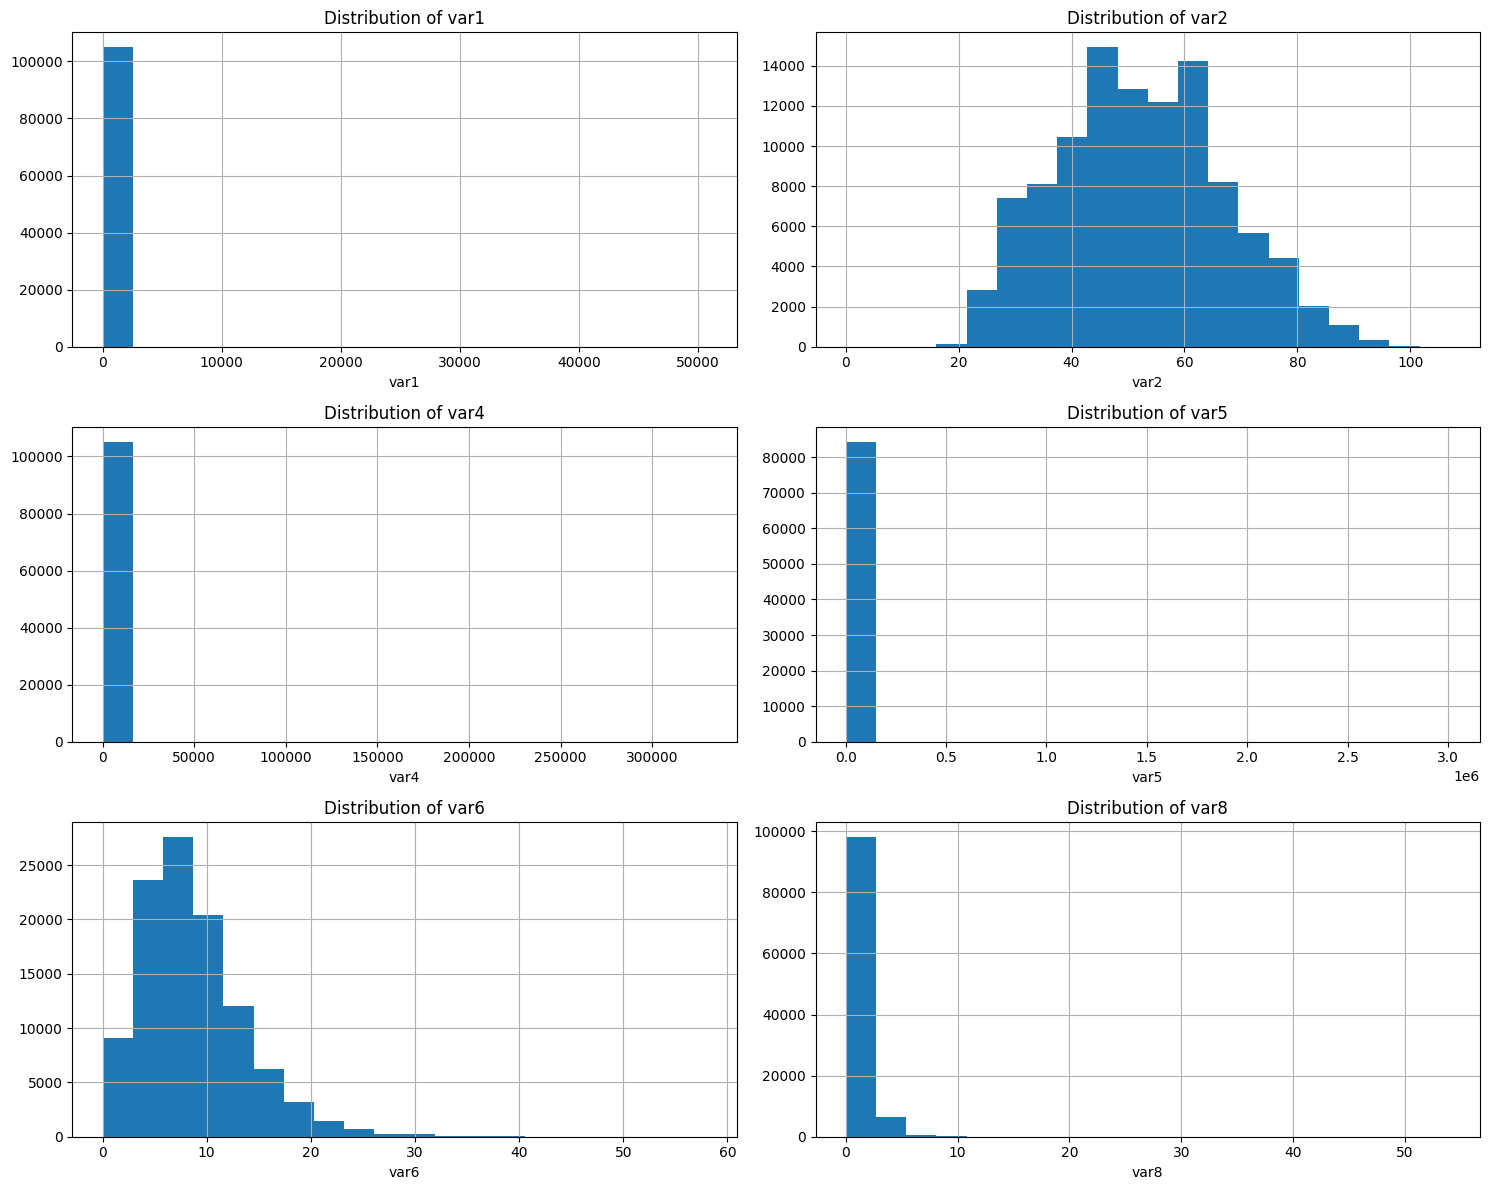

num columns without outliers distribution in train set
##########################################
var1 (filtered)
count    103948.000000
mean          0.313852
std           0.345733
min           0.000000
10%           0.002857
30%           0.042876
50%           0.151434
70%           0.432854
90%           0.964288
max           1.092091
Name: var1, dtype: float64
##########################################
var2 (filtered)
count    104125.000000
mean         51.940024
std          14.404788
min           0.000000
10%          32.000000
30%          43.000000
50%          52.000000
70%          60.000000
90%          71.000000
max          87.000000
Name: var2, dtype: float64
##########################################
var4 (filtered)
count    103948.000000
mean        270.194909
std         784.403078
min           0.000000
10%           0.029618
30%           0.211332
50%           0.361749
70%           0.630080
90%        1068.000000
max        4998.000000
Name: var4, dtype: float

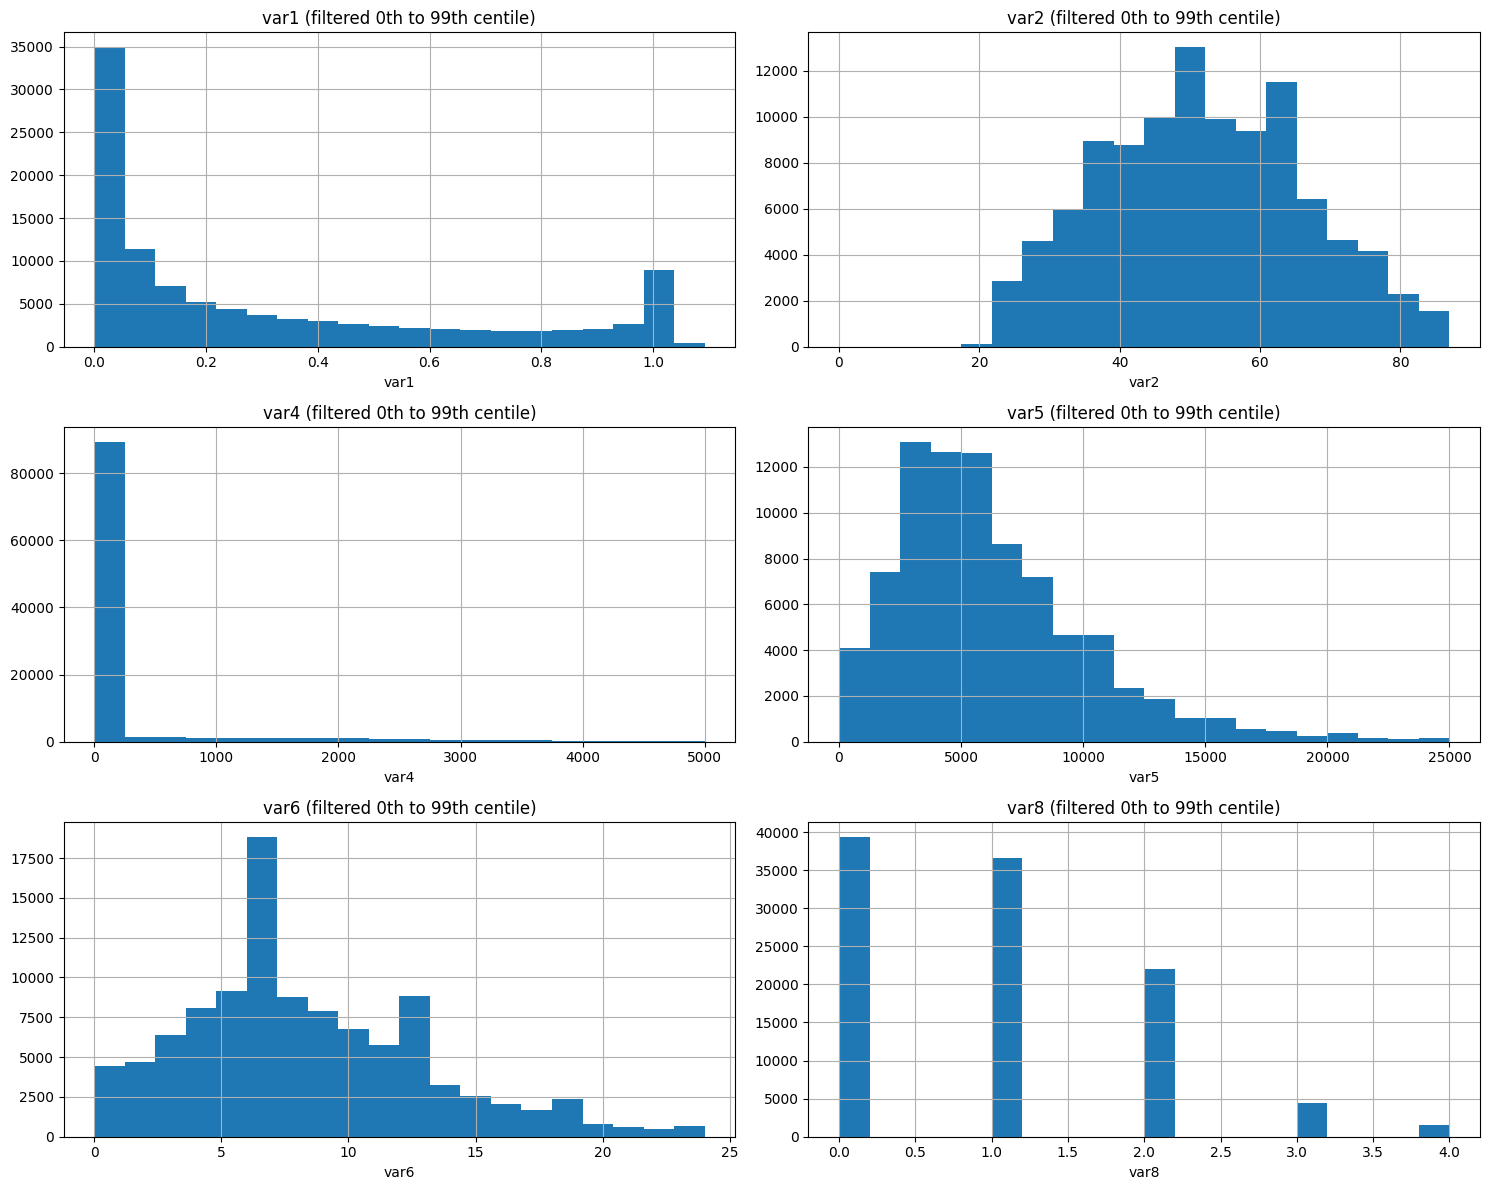

In [ ]:
# For categorical variables - display in 2 columns
def cat_summary(dataframe, cols):
    plt.figure(figsize=(15, 10))
    for i, col in enumerate(cols):
        plt.subplot(
            2, 2, i + 1
        )  # Arrange in 2x2 grid (adjust if you have more than 4 variables)
        print(f"##########################################\n{col}")
        print(
            pd.DataFrame(
                {
                    col: dataframe[col].value_counts(),
                    "Ratio": 100
                    * dataframe[col].value_counts()
                    / len(df_train),
                }
            )
        )
        sns.countplot(x=dataframe[col], data=dataframe)
        plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()


def num_summary(dataframe, cols):
    # For numerical variables - display in 2 columns
    num_rows = ceil(len(cols) / 2)  # Calculate number of rows needed
    plt.figure(figsize=(15, num_rows * 4))
    for i, col in enumerate(cols):
        quantiles = [0.01, 0.10, 0.30, 0.50, 0.70, 0.90, 0.99]
        print(f"##########################################\n{col}")
        print(dataframe[col].describe(quantiles).T)

        plt.subplot(num_rows, 2, i + 1)  # Arrange in 2 columns
        dataframe[col].hist(bins=20)
        plt.xlabel(col)
        plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()


def num_summary_filtered(dataframe, cols):
    # For filtered numerical variables
    num_rows = ceil(len(cols) / 2)  # Calculate number of rows needed
    plt.figure(figsize=(15, num_rows * 4))
    for i, col in enumerate(cols):
        # Calculate 0th and 99th centiles
        first_decile = dataframe[col].quantile(0.0)
        ninth_decile = dataframe[col].quantile(0.99)

        # Filter the dataframe
        filtered_df = dataframe[
            (dataframe[col] >= first_decile) & (dataframe[col] <= ninth_decile)
        ]

        quantiles = [0.10, 0.30, 0.50, 0.70, 0.90]
        print(f"##########################################\n{col} (filtered)")
        print(filtered_df[col].describe(quantiles).T)

        plt.subplot(num_rows, 2, i + 1)  # Arrange in 2 columns
        filtered_df[col].hist(bins=20)
        plt.xlabel(col)
        plt.title(f"{col} (filtered 0th to 99th centile)")
    plt.tight_layout()
    plt.show()


print("TARGET distribution in train set")
cat_summary(df_train, ["TARGET"])

print("cat columns distribution in train set")
cat_summary(df_train, cat_cols)

print("num columns distribution in train set")
num_summary(df_train, num_cols)

print("num columns without outliers distribution in train set")
num_summary_filtered(df_train, num_cols)


##########################################
var3
       var3      Ratio
var3                  
0     37761  35.963542
1      4832   4.601992
2      1416   1.348597
3       503   0.479057
4       229   0.218099
5       110   0.104764
98       77   0.073335
6        44   0.041906
7        13   0.012381
8         8   0.007619
9         5   0.004762
10        2   0.001905
96        1   0.000952
11        1   0.000952
##########################################
var7
       var7      Ratio
var7                  
0     42557  40.531248
1      1517   1.444789
2       454   0.432389
3       204   0.194289
4        94   0.089526
98       77   0.073335
5        34   0.032382
6        26   0.024762
7        17   0.016191
8         6   0.005714
9         4   0.003810
11        3   0.002857
10        2   0.001905
13        2   0.001905
12        2   0.001905
96        1   0.000952
14        1   0.000952
15        1   0.000952
##########################################
var9
       var9      Ratio
var9 

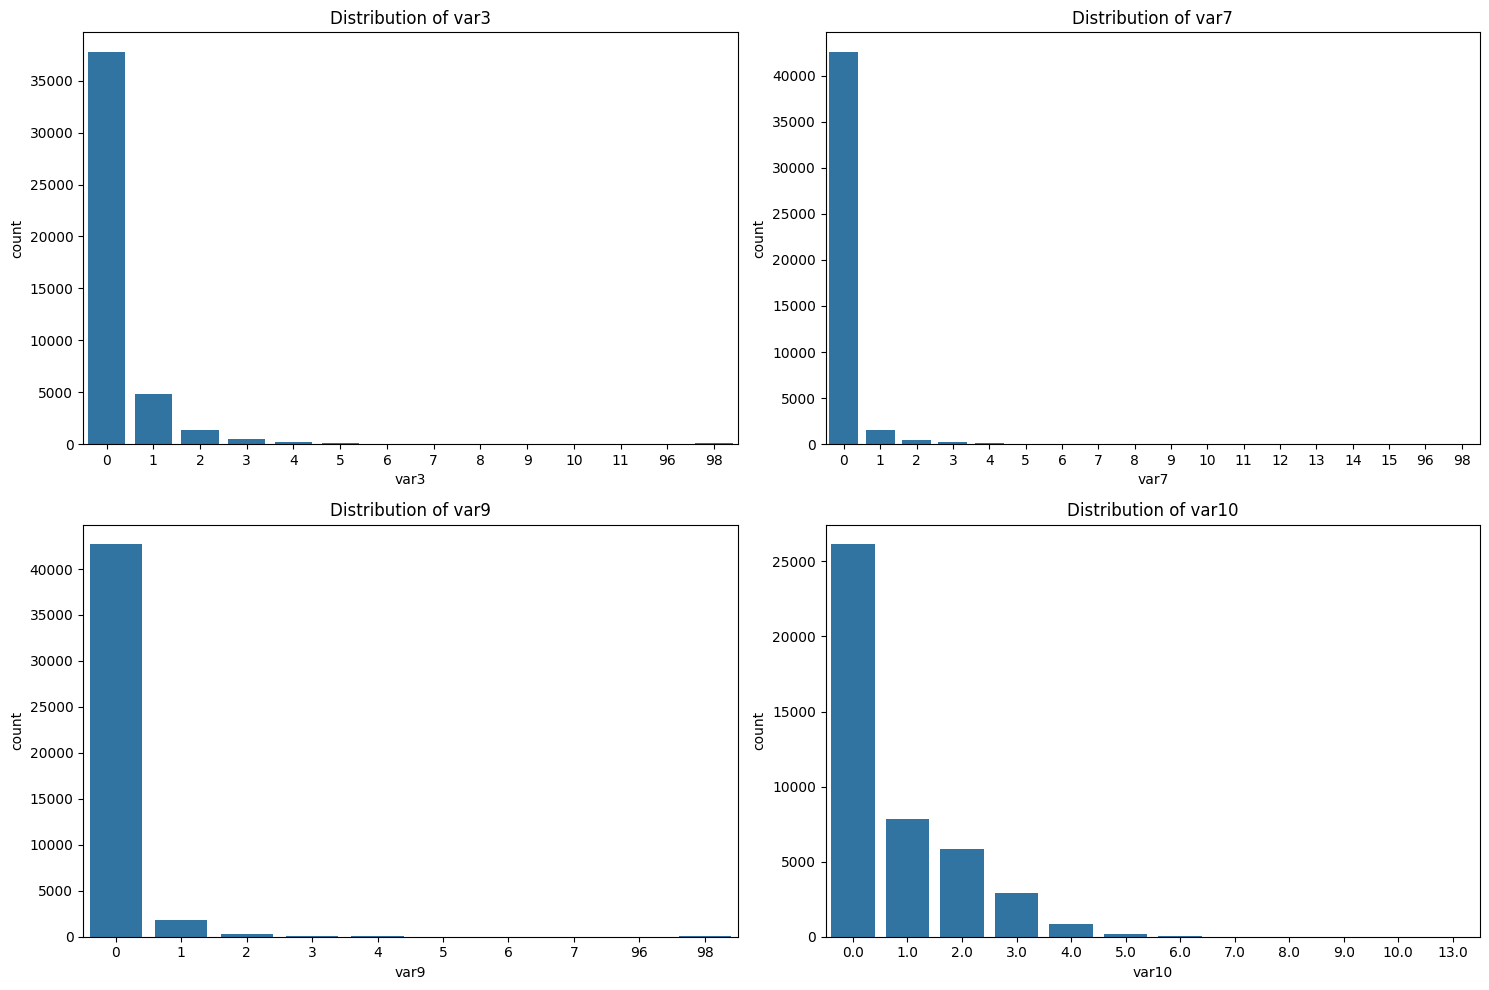

##########################################
var1
count    45002.000000
mean         5.990767
std        229.740401
min          0.000000
1%           0.000000
10%          0.002903
30%          0.042844
50%          0.150139
70%          0.441307
90%          0.978021
99%          1.093975
max      22000.000000
Name: var1, dtype: float64
##########################################
var2
count    45002.000000
mean        52.374983
std         14.778437
min         21.000000
1%          24.000000
10%         33.000000
30%         44.000000
50%         52.000000
70%         61.000000
90%         72.000000
99%         87.000000
max        109.000000
Name: var2, dtype: float64
##########################################
var4
count     45002.000000
mean        349.218744
std        1872.514607
min           0.000000
1%            0.000000
10%           0.030910
30%           0.213509
50%           0.367172
70%           0.651224
90%        1278.000000
99%        4920.980000
max      307001.00000

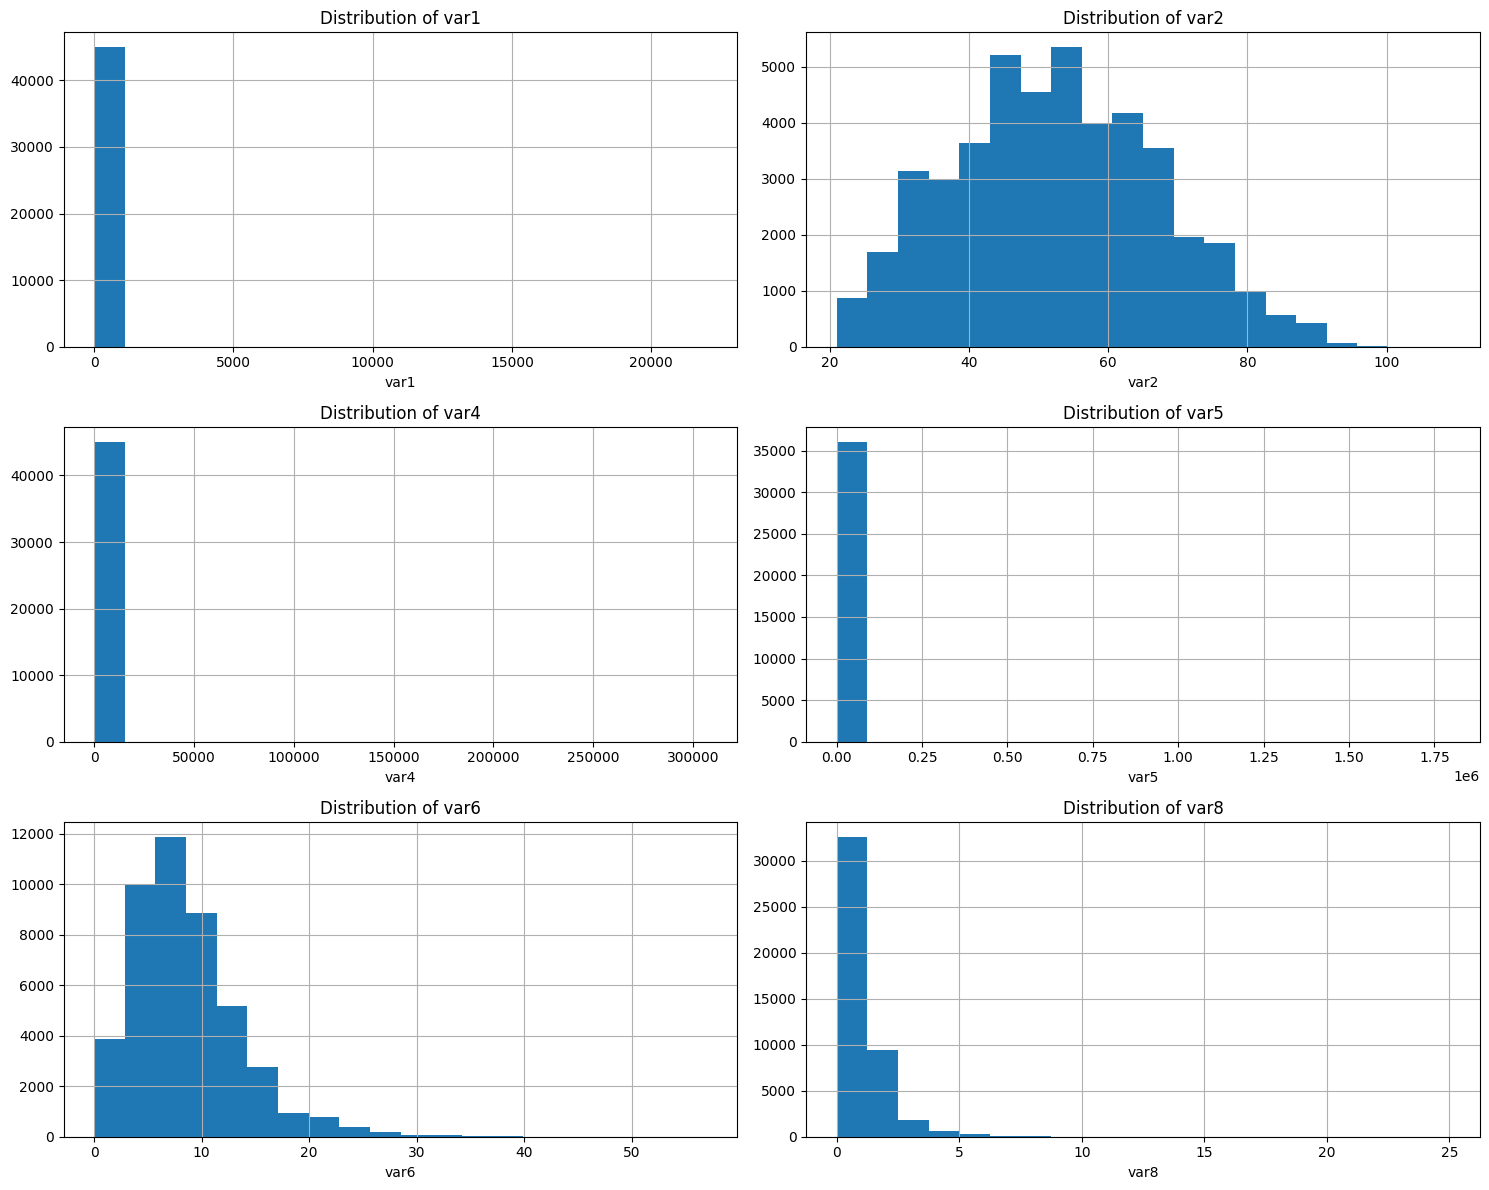

##########################################
var1 (filtered)
count    44551.000000
mean         0.309971
std          0.343987
min          0.000000
10%          0.002802
30%          0.042022
50%          0.145548
70%          0.427863
90%          0.955758
max          1.093837
Name: var1, dtype: float64
##########################################
var2 (filtered)
count    44599.000000
mean        52.031211
std         14.391277
min         21.000000
10%         33.000000
30%         44.000000
50%         52.000000
70%         60.000000
90%         71.000000
max         87.000000
Name: var2, dtype: float64
##########################################
var4 (filtered)
count    44551.000000
mean       267.632016
std        770.900211
min          0.000000
10%          0.030084
30%          0.211160
50%          0.363106
70%          0.633991
90%       1097.000000
max       4919.000000
Name: var4, dtype: float64
##########################################
var5 (filtered)
count    35682.000000
m

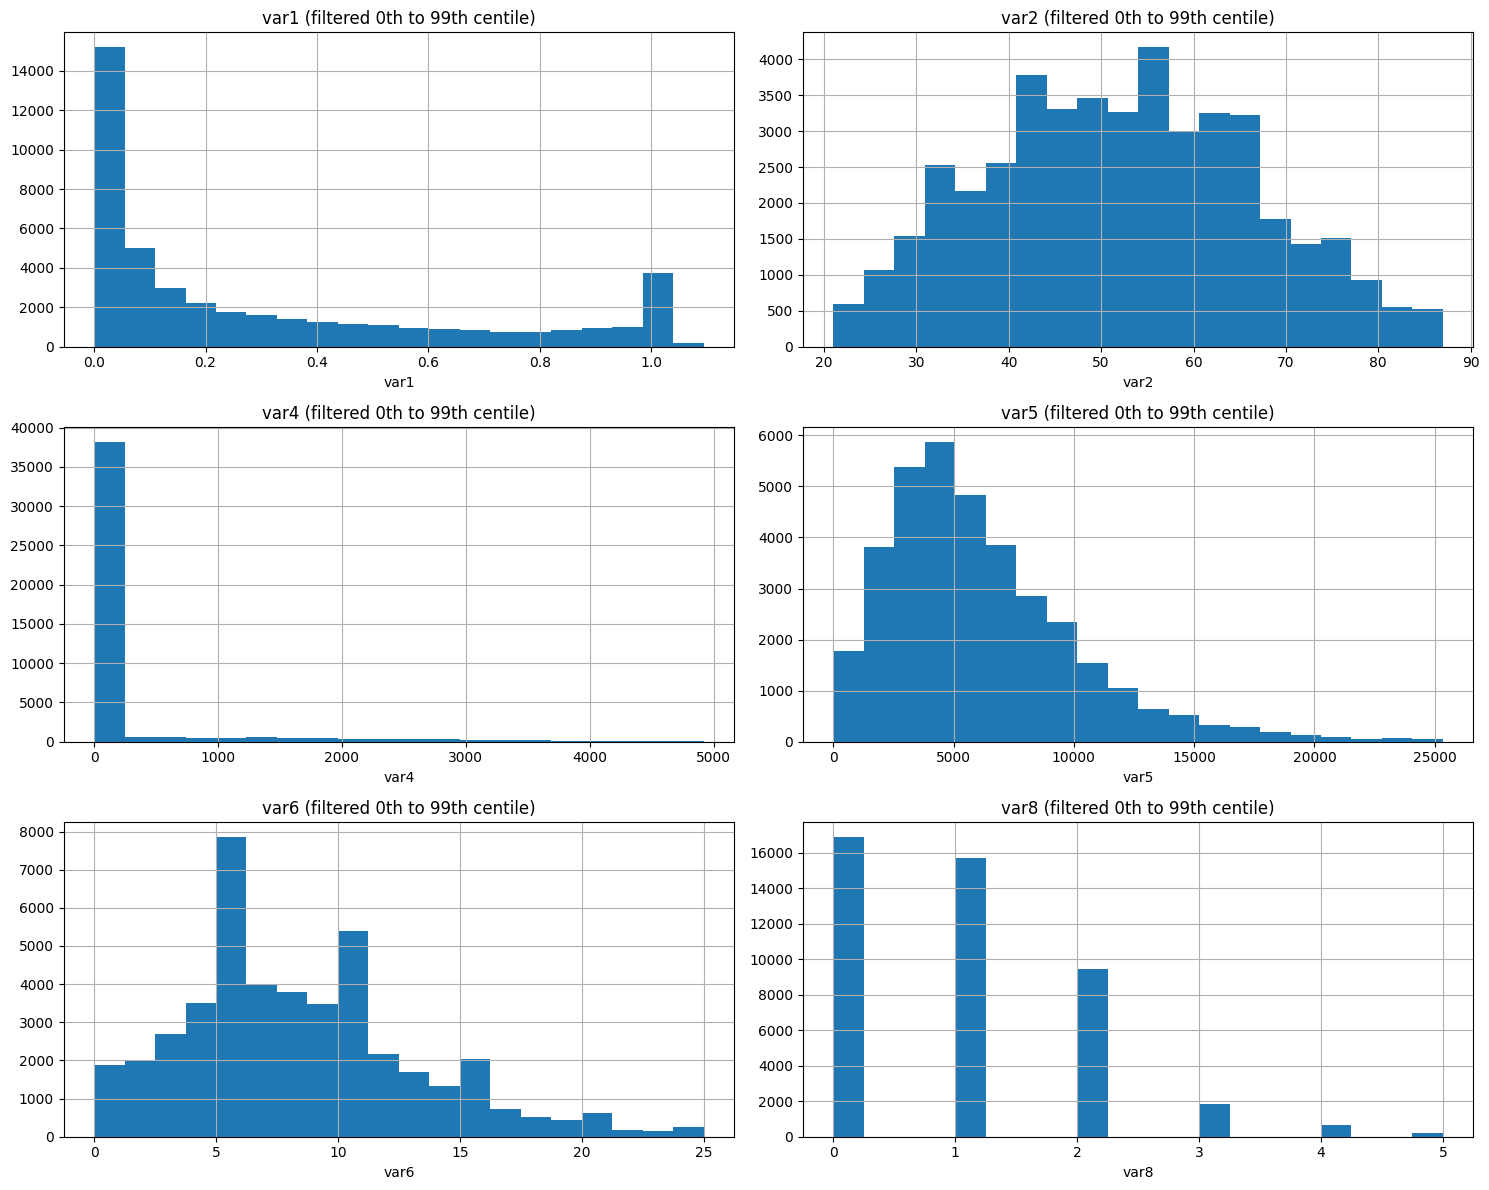

In [18]:
# and for test set:
cat_summary(df_test, cat_cols)
num_summary(df_test, num_cols)
num_summary_filtered(df_test, num_cols)

**var1, var5, var8 have extreme values, maybe delete these rows**

**var4 is not only extreme values but a very skewed repartition**


In [ ]:
# Au vu des graphiques, retirer que le 99eme centile est interessant
def outlier_thresholds(dataframe, col_name, q1=0.0, q3=0.95):
    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return low_limit, up_limit


def check_outlier(dataframe, col_name, ax=None):
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)
    outliers = dataframe[
        (dataframe[col_name] > up_limit) | (dataframe[col_name] < low_limit)
    ]
    if ax is not None:
        sns.boxplot(x=dataframe[col_name], ax=ax)
        ax.set_title(f"Outliers in {col_name}")
    return outliers.any(axis=None)


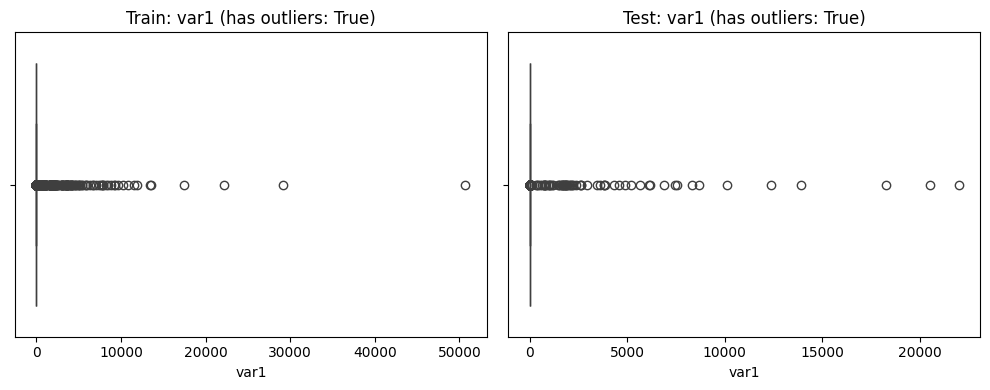

var1 - Train has outliers: True, Test has outliers: True


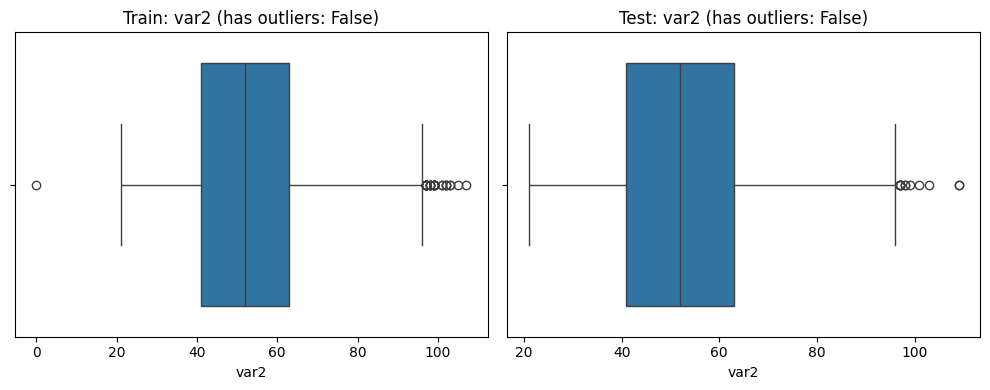

var2 - Train has outliers: False, Test has outliers: False


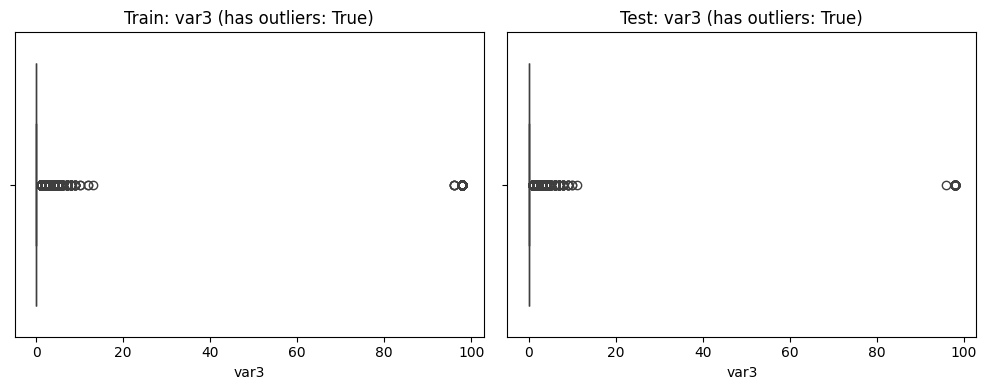

var3 - Train has outliers: True, Test has outliers: True


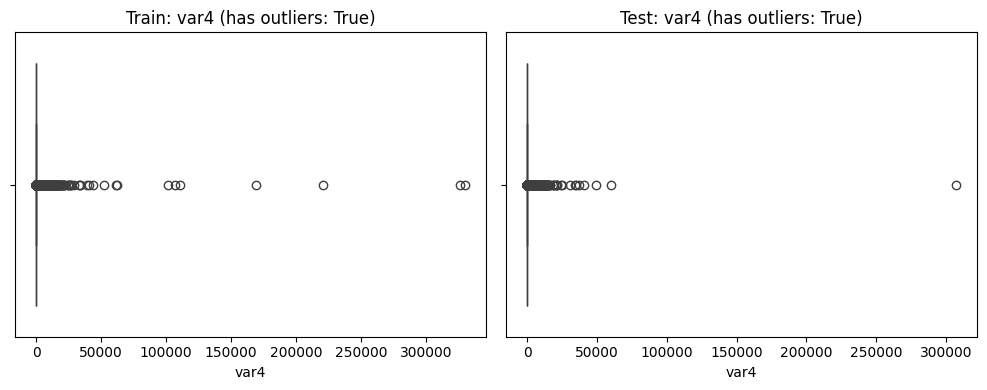

var4 - Train has outliers: True, Test has outliers: True


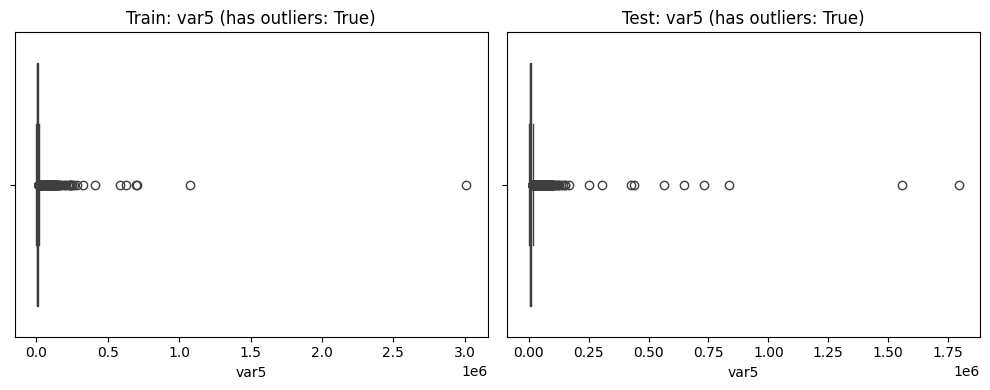

var5 - Train has outliers: True, Test has outliers: True


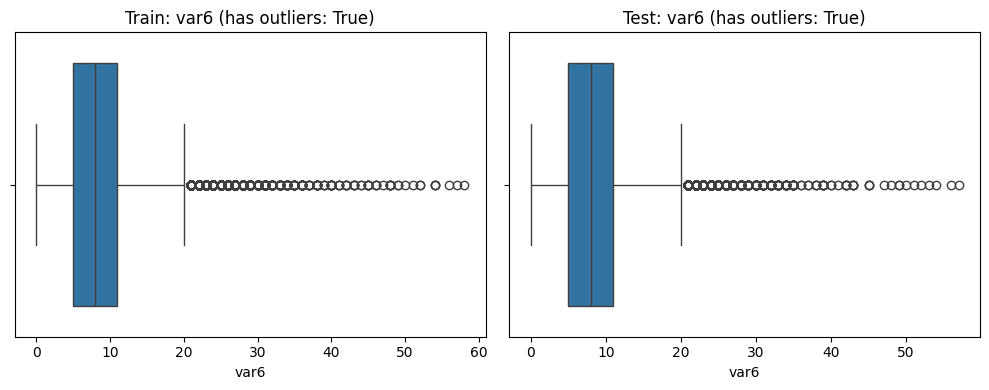

var6 - Train has outliers: True, Test has outliers: True


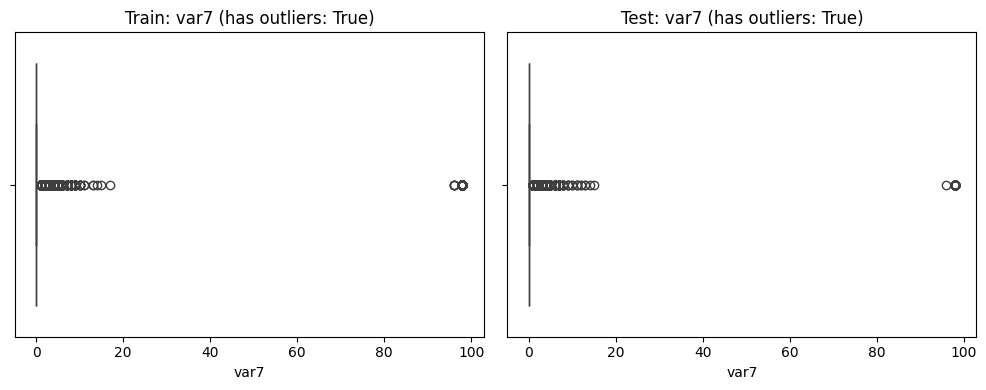

var7 - Train has outliers: True, Test has outliers: True


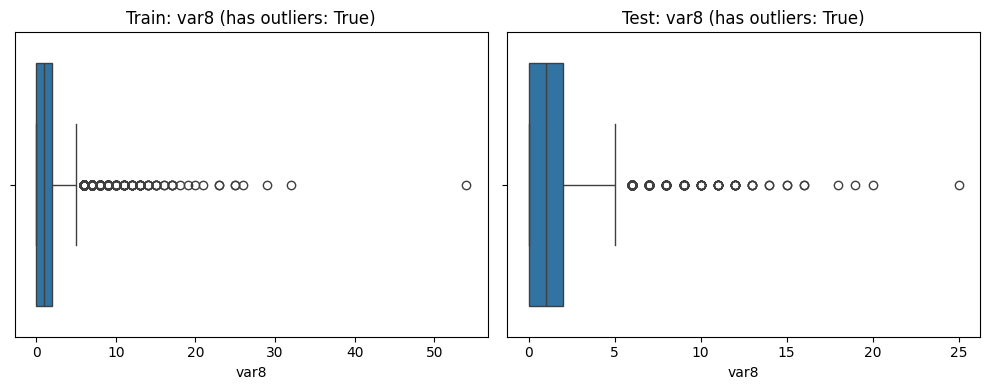

var8 - Train has outliers: True, Test has outliers: True


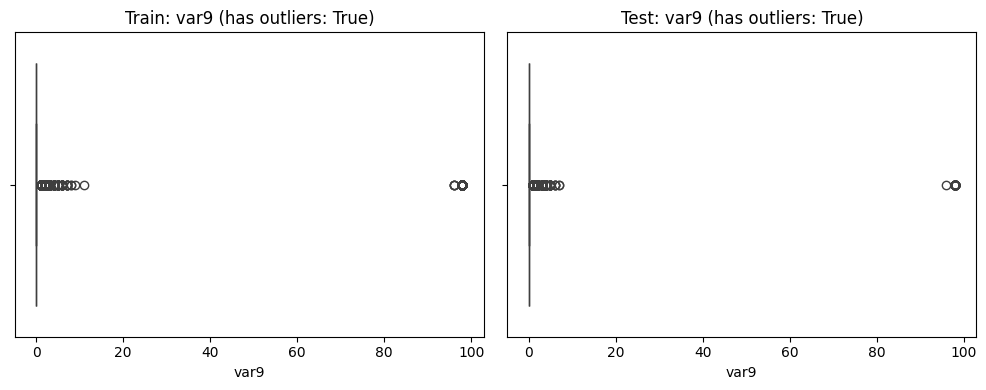

var9 - Train has outliers: True, Test has outliers: True


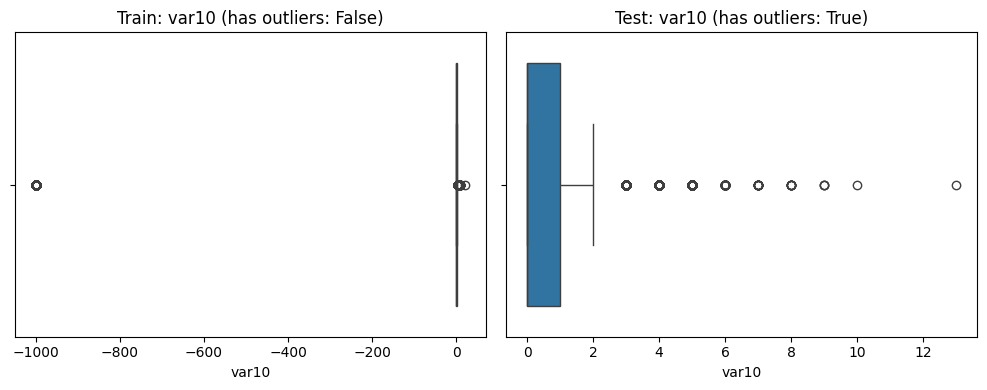

var10 - Train has outliers: False, Test has outliers: True


In [ ]:
# Display outliers side by side for each variable
for col in df_train.columns:
    if col == "TARGET":
        continue
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    # Check and plot outliers for train set
    has_outlier_train = check_outlier(df_train, col, ax=ax1)
    ax1.set_title(f"Train: {col} (has outliers: {has_outlier_train})")

    # Check and plot outliers for test set
    has_outlier_test = check_outlier(df_test, col, ax=ax2)
    ax2.set_title(f"Test: {col} (has outliers: {has_outlier_test})")

    plt.tight_layout()
    plt.show()
    print(
        f"{col} - Train has outliers: {has_outlier_train}, Test has outliers: {has_outlier_test}"
    )

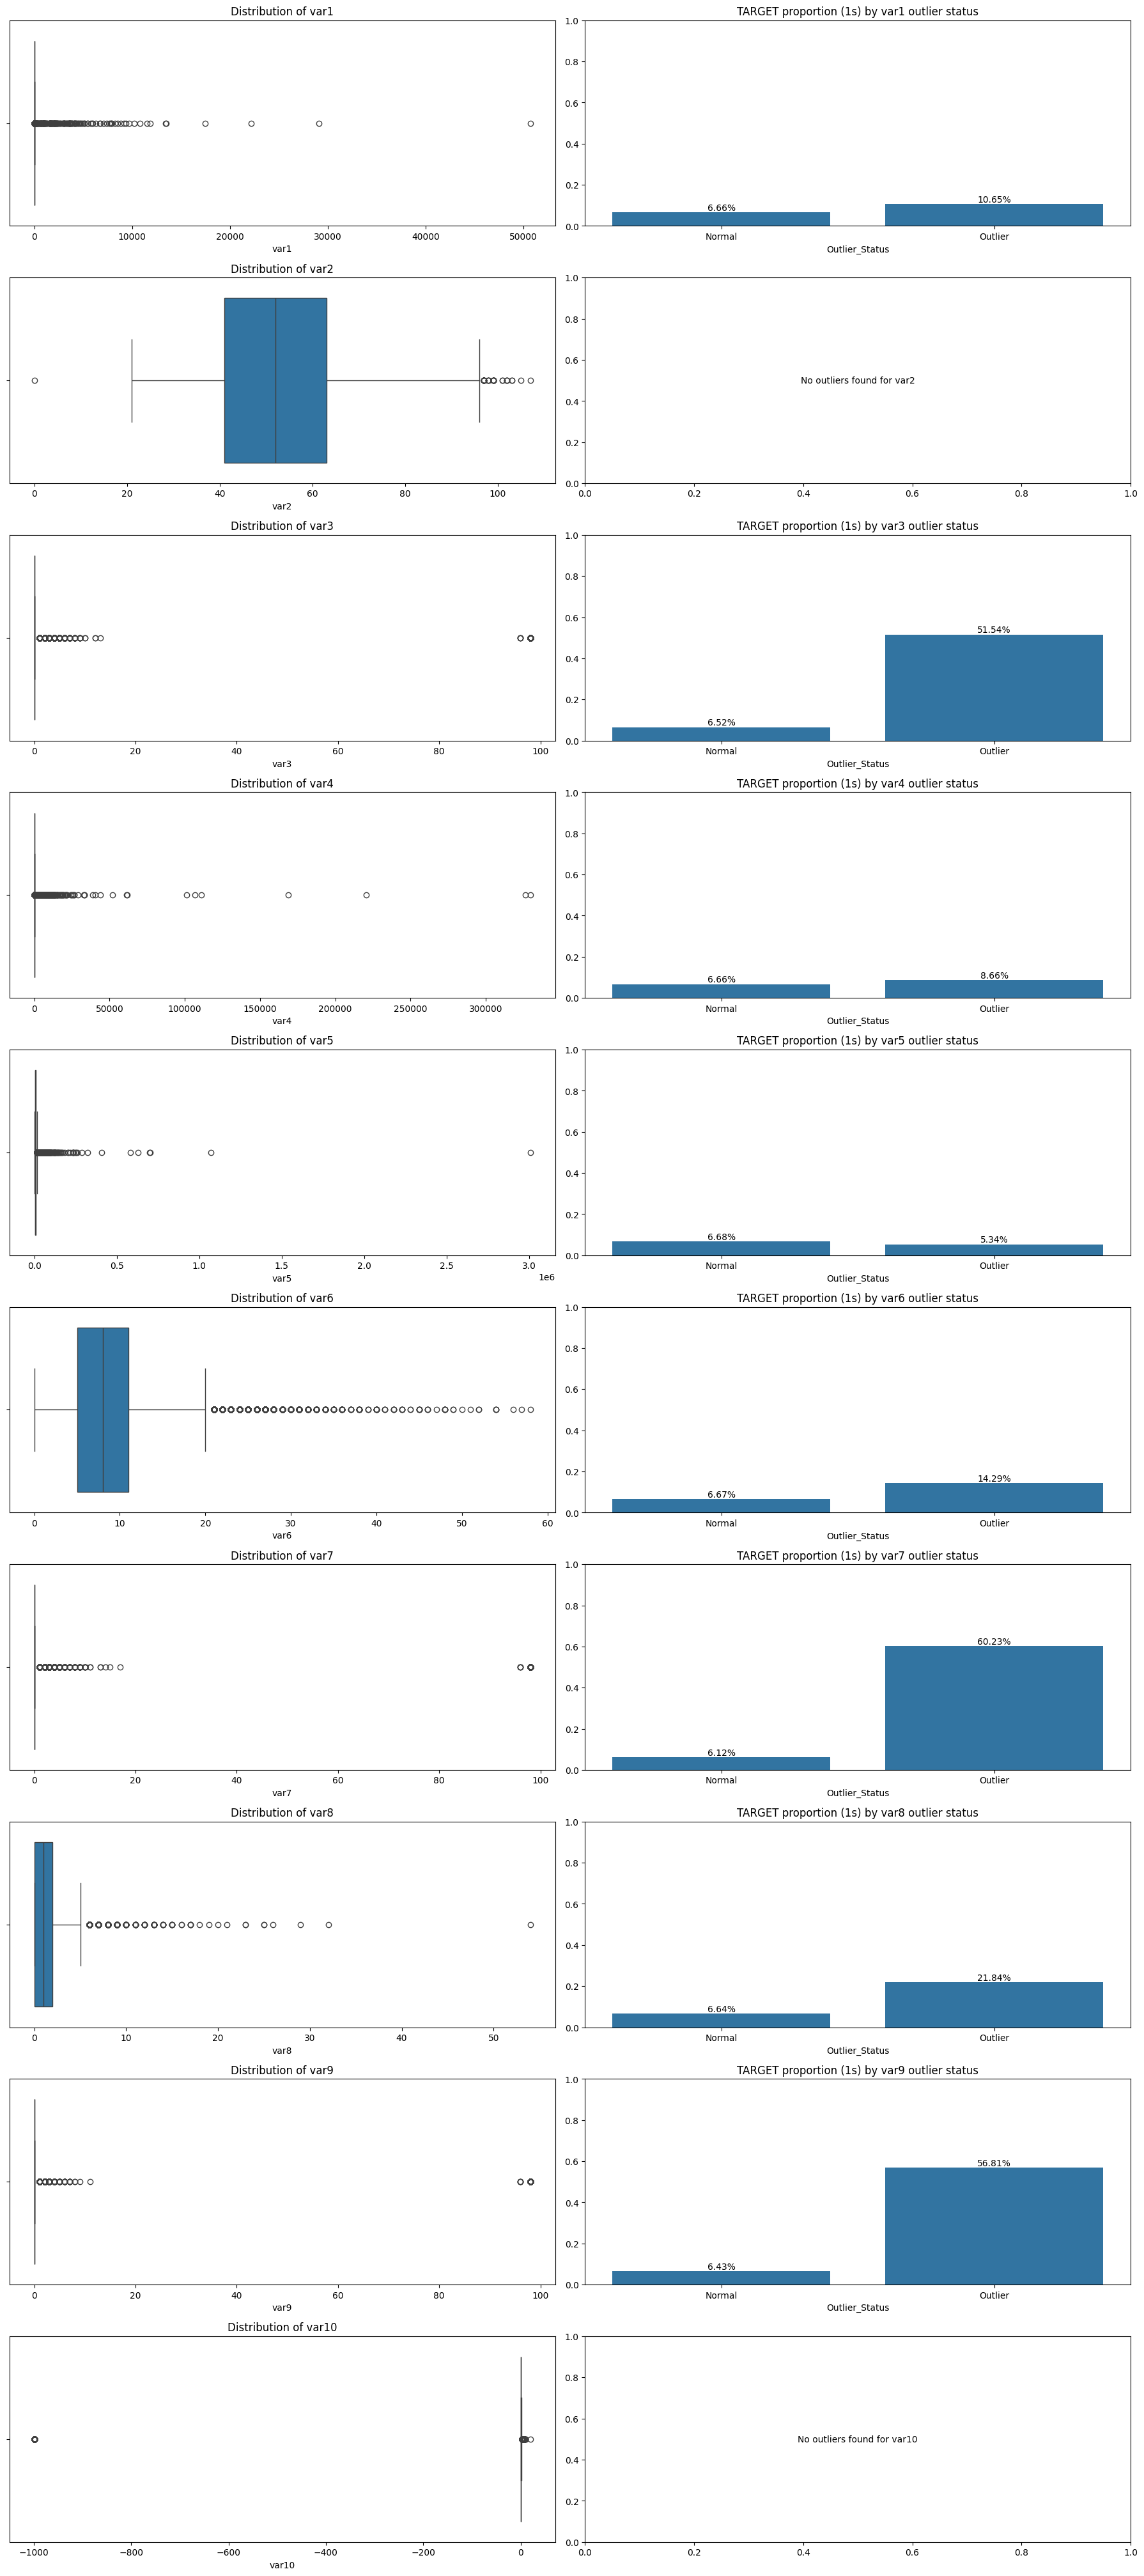

In [ ]:
# Function to identify outliers for a given column
def get_outliers(dataframe, col_name, q1=0, q3=0.95):
    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range

    # Get mask for outliers
    outlier_mask = (dataframe[col_name] > up_limit) | (
        dataframe[col_name] < low_limit
    )

    # Get outlier rows
    outlier_rows = dataframe[outlier_mask]

    return outlier_rows, outlier_mask


# Create a figure to display target distribution for outliers vs. non-outliers
plt.figure(figsize=(18, 4 * len(df_train.columns)))

for i, col in enumerate(df_train.columns):
    if col == "TARGET":
        continue
    # Get outliers
    outlier_rows, outlier_mask = get_outliers(df_train, col)

    # First subplot: Distribution of the variable
    plt.subplot(len(df_train.columns), 2, i * 2 + 1)
    sns.boxplot(x=df_train[col])
    plt.title(f"Distribution of {col}")

    # Second subplot: TARGET proportion by outlier status
    plt.subplot(len(df_train.columns), 2, i * 2 + 2)

    if outlier_mask.sum() > 0:
        # Create a categorical variable indicating outlier status
        outlier_status = ["Outlier" if x else "Normal" for x in outlier_mask]

        # Calculate TARGET proportion for outliers vs non-outliers
        outlier_df = pd.DataFrame(
            {"TARGET": df_train["TARGET"], "Outlier_Status": outlier_status}
        )

        # Plot TARGET proportion (since it's binary 0/1)
        target_props = outlier_df.groupby("Outlier_Status")["TARGET"].mean()
        ax = sns.barplot(x=target_props.index, y=target_props.values)

        # Add percentage labels on bars
        for p in ax.patches:
            ax.annotate(
                f"{p.get_height():.2%}",
                (p.get_x() + p.get_width() / 2.0, p.get_height()),
                ha="center",
                va="bottom",
            )

        plt.title(f"TARGET proportion (1s) by {col} outlier status")
    else:
        plt.text(
            0.5,
            0.5,
            f"No outliers found for {col}",
            horizontalalignment="center",
            verticalalignment="center",
        )

    plt.ylim(0, 1)


plt.tight_layout()
plt.show()

Number of rows with at least one outlier: 1333 (1.2695479913903123%)


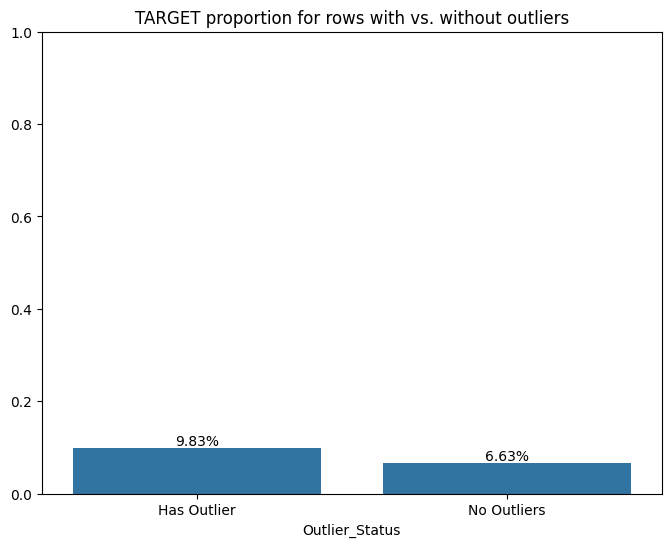

In [ ]:
# Create a combined mask for rows with at least one outlier in any column
any_outlier_mask = pd.Series(False, index=df_train.index)
for col in num_cols:
    _, col_outlier_mask = get_outliers(df_train, col)
    any_outlier_mask = any_outlier_mask | col_outlier_mask

# Count how many rows have at least one outlier
outlier_count = any_outlier_mask.sum()
print(
    f"Number of rows with at least one outlier: {outlier_count} ({outlier_count * 100 / len(df_train)}%)"
)

# Create a figure to analyze rows with any outliers
plt.figure(figsize=(8, 6))

outlier_status = [
    "Has Outlier" if x else "No Outliers" for x in any_outlier_mask
]
outlier_df = pd.DataFrame(
    {"TARGET": df_train["TARGET"], "Outlier_Status": outlier_status}
)

# Calculate and plot TARGET proportion
target_props = outlier_df.groupby("Outlier_Status")["TARGET"].mean()
ax = sns.barplot(x=target_props.index, y=target_props.values)

# Add percentage labels on bars
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2%}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
    )

plt.title("TARGET proportion for rows with vs. without outliers")
plt.ylim(0, 1)

plt.show()


Les outliers ont plus de classe 1 que le reste de la population : on ne peut pas le négliger ; avec certaines var qui ont plus de poids.

Pour les variables float : je pense qu'on peut remplacer par un threshold

Pour les int, je sais pas, car ce sont des catégories, mais threshold peut être approprié


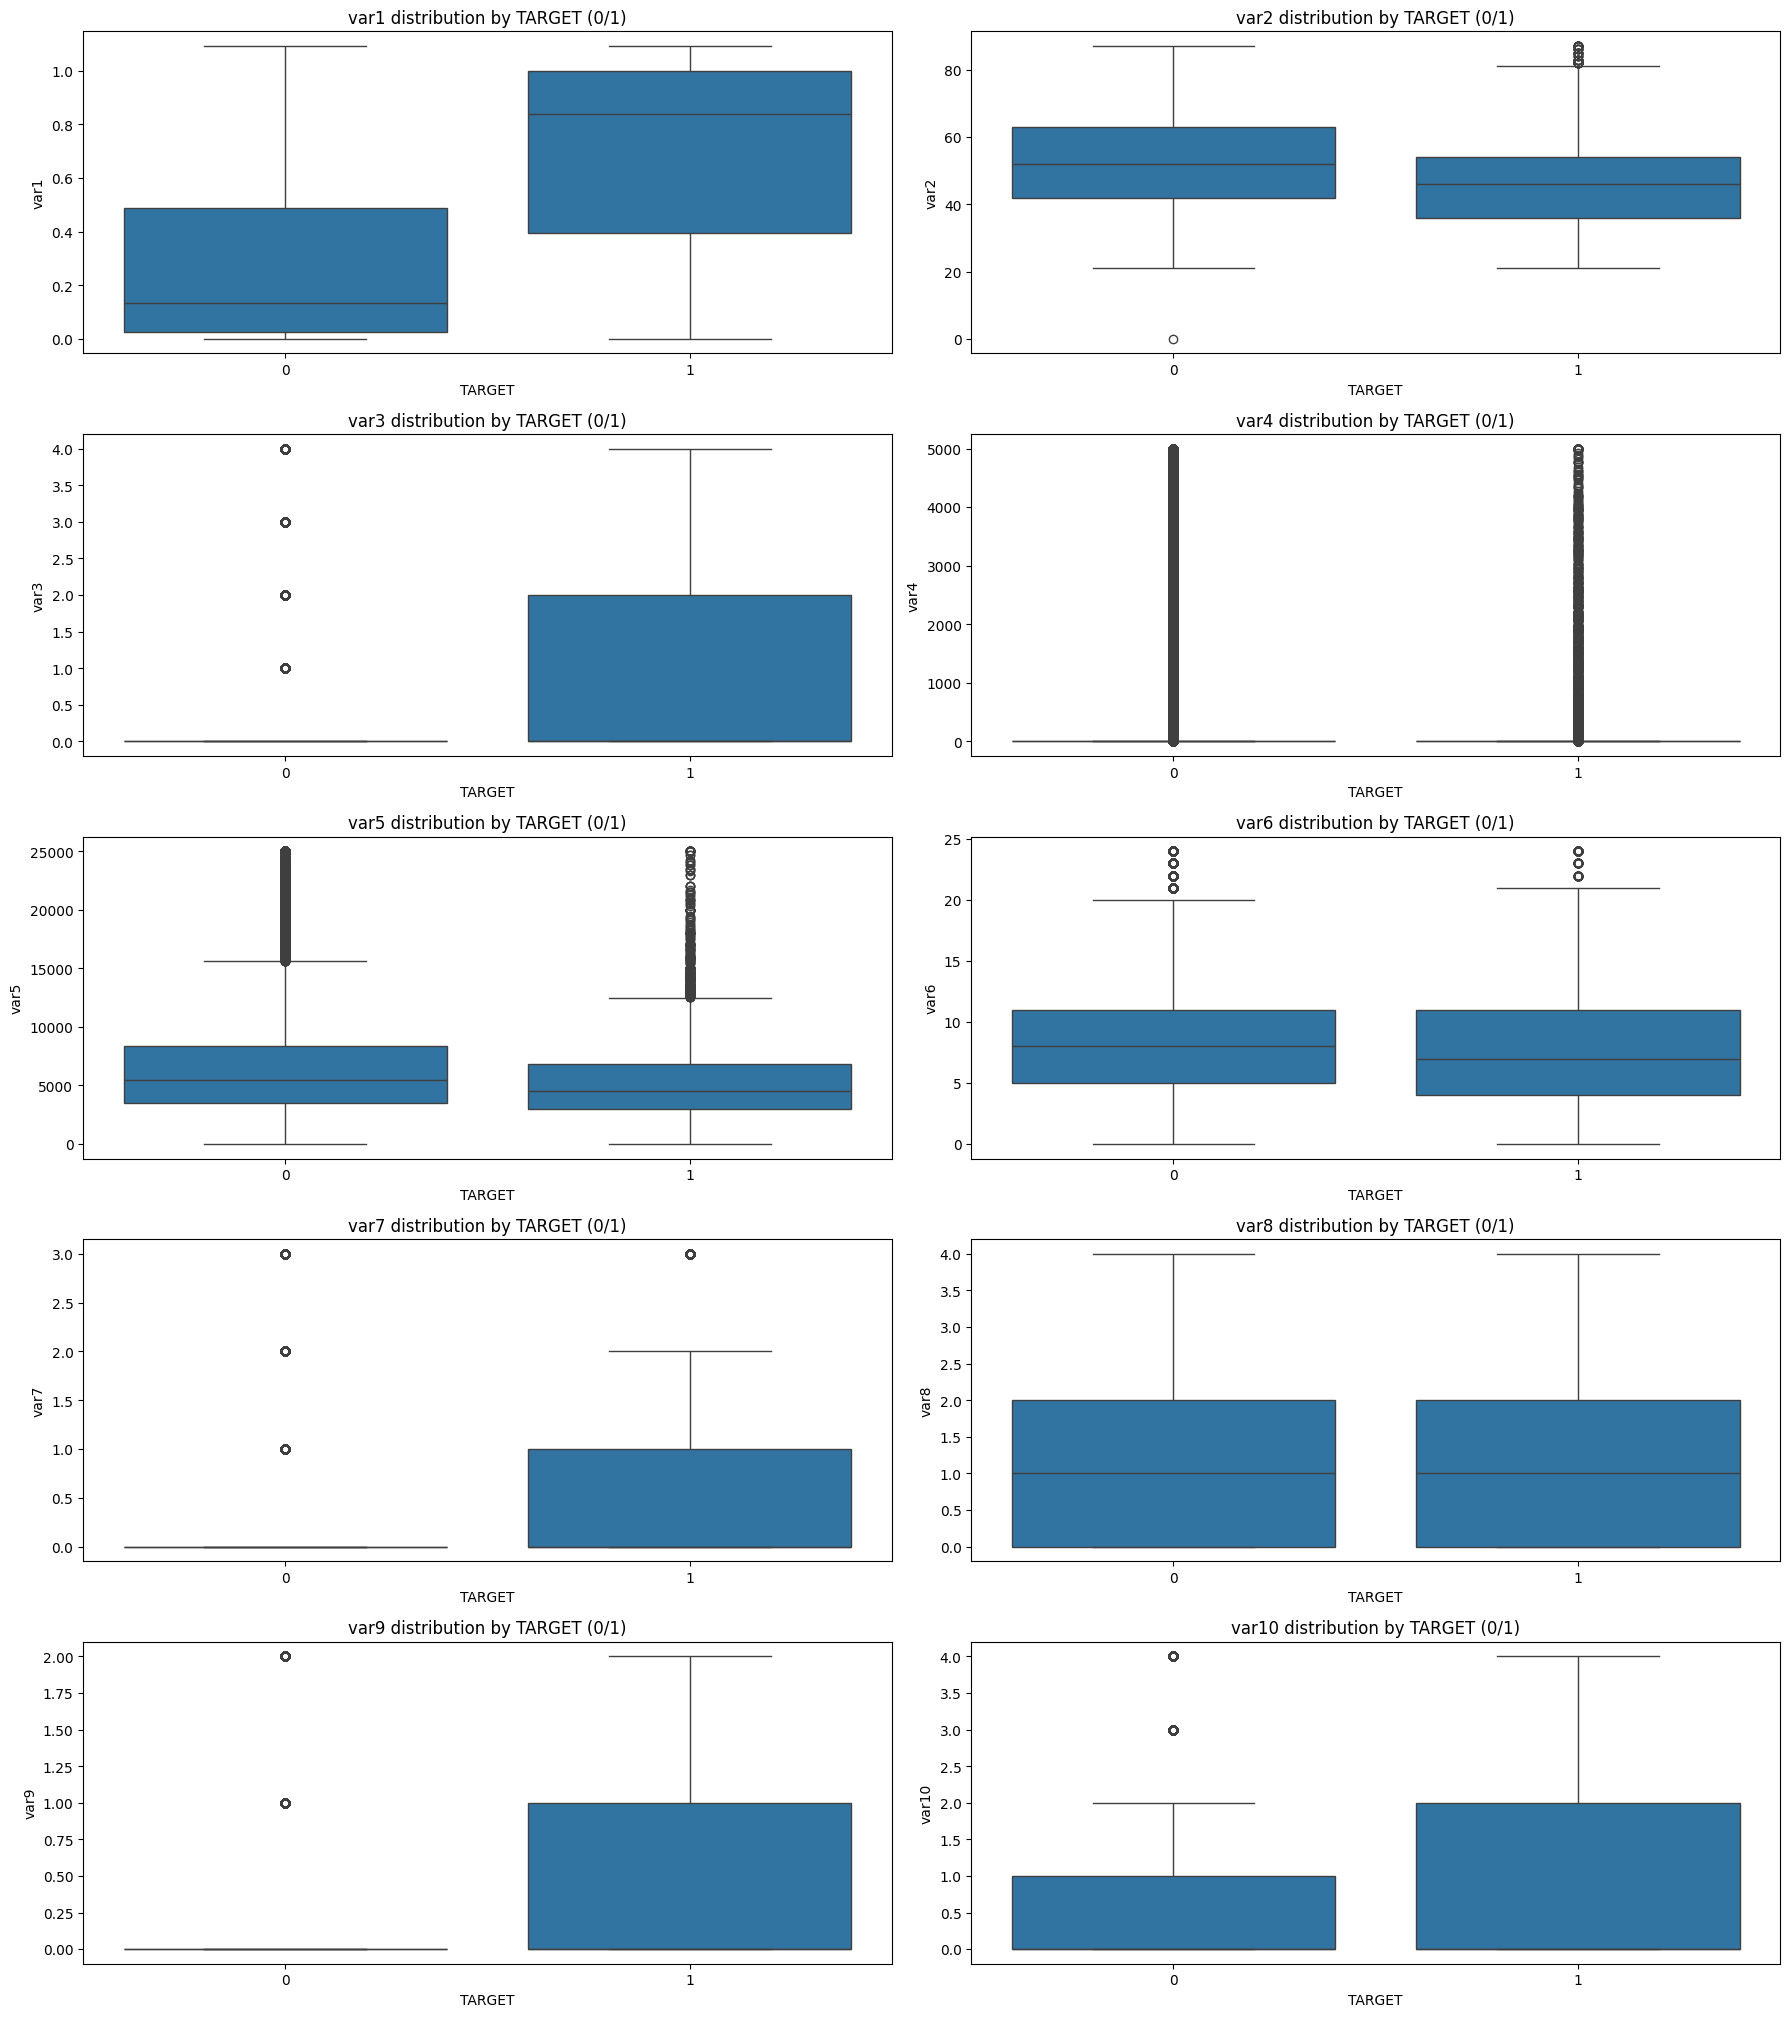

In [ ]:
plt.figure(figsize=(18, 4 * len(df_train.columns)))

for i, col in enumerate(df_train.columns):
    if col == "TARGET":
        continue
    plt.subplot(len(df_train.columns), 2, i + 1)

    # Show boxplot of the variable split by TARGET value (0/1)
    sns.boxplot(x="TARGET", y=col, data=df_train)
    plt.title(f"{col} distribution by TARGET (0/1)")

plt.tight_layout()
plt.show()


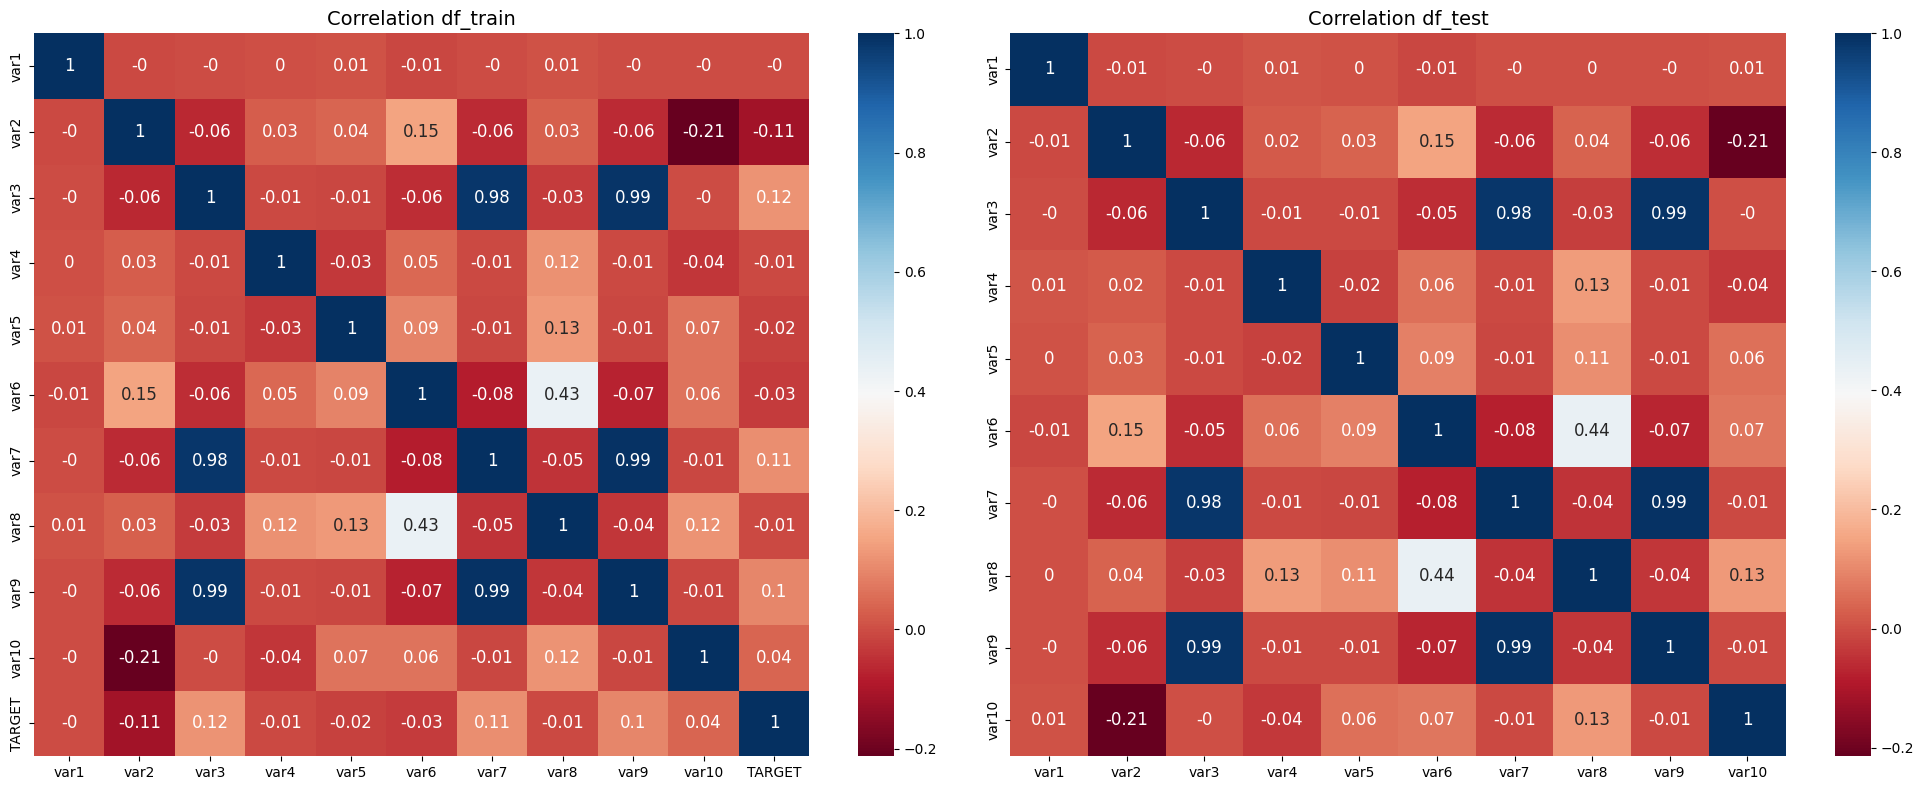

In [ ]:
def plot_correlations_side_by_side(
    dataframe1,
    dataframe2,
    title1="Correlation df_train",
    title2="Correlation df_test",
):
    # Compute correlations
    corr1 = dataframe1.corr()
    corr2 = dataframe2.corr()

    # Create figure with two subplots side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

    # Plot first correlation matrix
    corr_values1 = corr1.round(2)
    sns.heatmap(
        corr1, cmap="RdBu", annot=corr_values1, annot_kws={"size": 12}, ax=ax1
    )
    ax1.set_title(title1, fontsize=14)

    # Plot second correlation matrix
    corr_values2 = corr2.round(2)
    sns.heatmap(
        corr2, cmap="RdBu", annot=corr_values2, annot_kws={"size": 12}, ax=ax2
    )
    ax2.set_title(title2, fontsize=14)

    # Adjust layout
    plt.tight_layout()
    plt.show()


plot_correlations_side_by_side(df_train, df_test)

var3-var7-var9 très corrélées -> on peut en supprimer 2 des 3

var6-var8 assez corrélées, faudra faire du traitement pour ça

var2-var10 légère corrélation, garder à l'esprit

train et test ont les mêmes corrélations
